In [51]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
data = pd.read_csv("Datasets/student_performance_dataset.csv")
df = pd.DataFrame(data)
print(df.head())

   student_id  age  ... final_exam_score performance_category
0           0   21  ...               32                  Low
1           1   19  ...               59               Medium
2           2   16  ...               34                  Low
3           3   19  ...               60               Medium
4           4   17  ...               77                 High

[5 rows x 32 columns]


In [53]:
target = "final_exam_score"
drop_columns = ["student_id", "performance_category", "final_exam_score"]

X = df.drop(columns=drop_columns)
y = df[target]

In [54]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.drop(
    ["student_id", "final_exam_score"]
).tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.drop(["performance_category"]).tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

processor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [55]:
model = Pipeline([
    ("processoring", processor),
    ("regressor", LinearRegression())
])


In [56]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,
                                                 random_state=42)

In [57]:
model.fit(X_train,y_train)

,steps,"[('processoring', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
y_pred = model.predict(X_test)
print("Prediction: ",y_pred)

Prediction:  [ 46.07950585  58.67157057  56.1945842   46.20236625  41.88305319
  55.24537573  77.7311772   53.71180193  88.48712528  56.46839016
  40.74797528  69.74715648  48.0343269   53.98978197  45.3094379
  50.27938175  52.11228481  29.6162707   55.47701913  93.32661652
  62.2187158   33.22912037  64.89591209  58.41305162  42.29736168
  66.69215429  75.13903967  67.16173557  46.60209831  67.68651528
  44.81590525  49.25225842  50.31947294  42.33505854  25.232451
  56.1960929   40.3890046   50.9395397   62.89299911  14.80004357
  82.70321387  71.7674635   67.47723103  52.99351008  65.73412617
  41.35895178  53.26149809  26.16820866  48.9256654   36.54314219
  32.2530384   15.15010298  70.59608476  83.82679335  47.17756646
  29.66816092  83.00086578  48.16354021  59.96340863  57.46917475
  51.20276531  56.25435608  39.15943652  66.47194603  84.70737644
  75.42749785  67.86701621  57.47491387  27.87881996  56.8576959
  68.51352332  49.9748726   69.93092825  61.93145702  64.0655697
  

In [59]:
mse = mean_squared_error(y_test,y_pred)
print("Mean Squaraed Error: ",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error: ",mae)
r2 = r2_score(y_test,y_pred)
print("r2 Score: ",r2)

Mean Squaraed Error:  64.97761568080354
Mean Absolute Error:  6.51386308191082
r2 Score:  0.8059132917534717


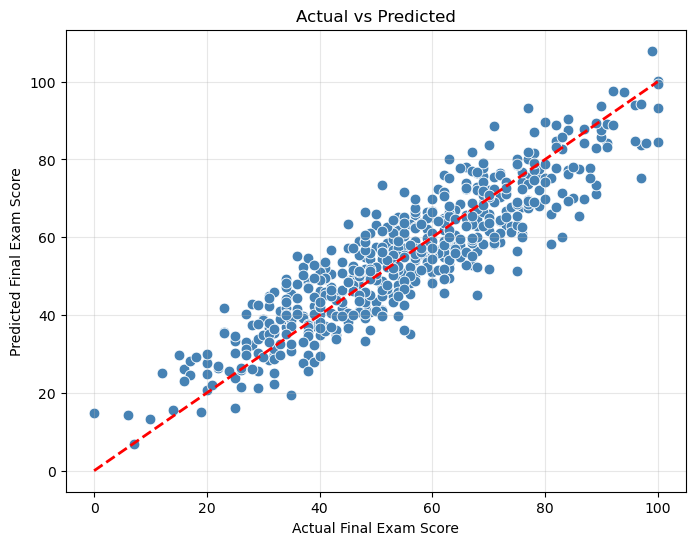

In [60]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, color="steelblue", s=60)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)
plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.show()